# Experiment 5: Effective Complexity Through Parameter Norms

### Objective
To investigate whether parameter count alone describes the complexity of a learned solution, or whether the actual parameter values and their norms also differ between generalizing and memorizing solutions.

### Experimental Configuration

- Dataset: MNIST
- Width: 2048
- Parameters: 10,020,874
- Optimizer: Adam
- Learning rate: 0.001
- Batch size: 128
- Epochs: 100
- Labels: Normal vs Random
- Complexity measure: Total L2 parameter norm

Device: cuda
GPU: Tesla T4


100%|██████████| 9.91M/9.91M [00:00<00:00, 14.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 340kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.19MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.4MB/s]



Training samples: 60000
Test samples: 10000

Model width: 2048
Total parameters: 10020874

Training: Normal Labels
Epoch  10/100 | Train Loss: 0.0201 | Train Acc: 99.45% | Test Loss: 0.0922 | Test Acc: 97.93% | Gap: 1.52%
Epoch  20/100 | Train Loss: 0.0105 | Train Acc: 99.74% | Test Loss: 0.0865 | Test Acc: 98.42% | Gap: 1.32%
Epoch  30/100 | Train Loss: 0.0059 | Train Acc: 99.85% | Test Loss: 0.1336 | Test Acc: 98.27% | Gap: 1.58%
Epoch  40/100 | Train Loss: 0.0083 | Train Acc: 99.83% | Test Loss: 0.2088 | Test Acc: 97.90% | Gap: 1.93%
Epoch  50/100 | Train Loss: 0.0128 | Train Acc: 99.78% | Test Loss: 0.1498 | Test Acc: 98.29% | Gap: 1.49%
Epoch  60/100 | Train Loss: 0.0135 | Train Acc: 99.75% | Test Loss: 0.1617 | Test Acc: 98.46% | Gap: 1.29%
Epoch  70/100 | Train Loss: 0.0120 | Train Acc: 99.84% | Test Loss: 0.1913 | Test Acc: 98.40% | Gap: 1.44%
Epoch  80/100 | Train Loss: 0.0012 | Train Acc: 99.97% | Test Loss: 0.1796 | Test Acc: 98.45% | Gap: 1.52%
Epoch  90/100 | Train Loss: 

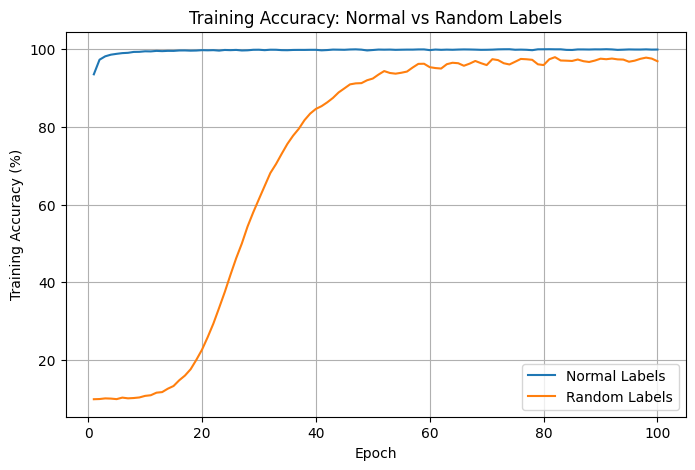

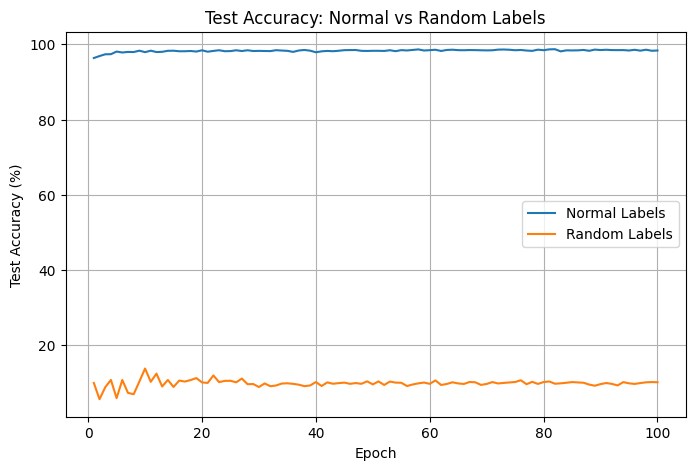

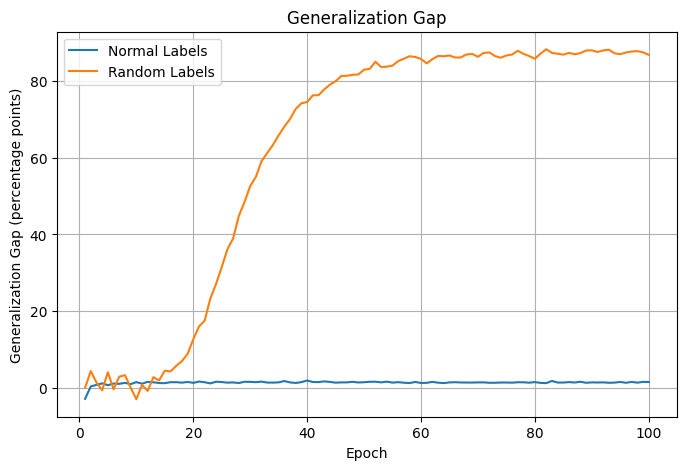

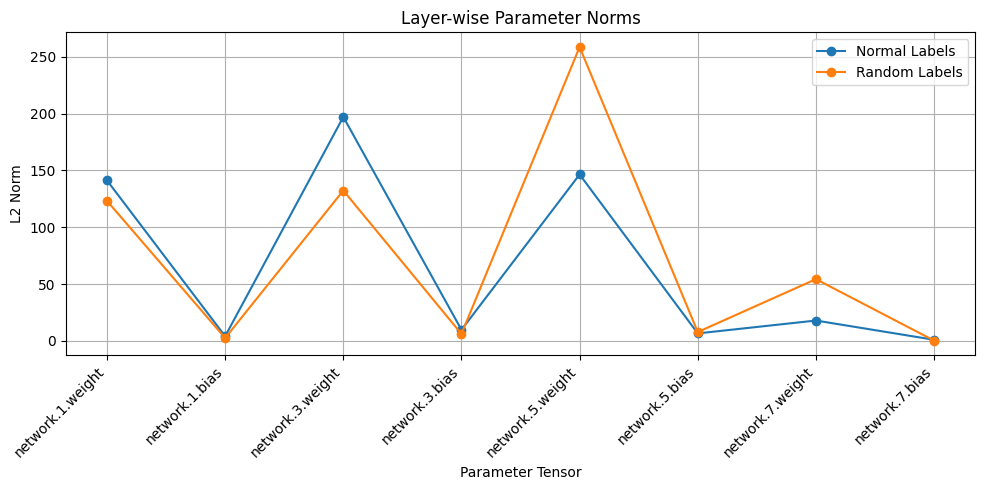

In [ ]:
# ============================================================
# EXPERIMENT 5
# Effective Complexity: Parameter Norms
# Normal Labels vs Random Labels
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import pandas as pd
import matplotlib.pyplot as plt
import time
import copy


# ============================================================
# 1. DEVICE
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


# ============================================================
# 2. REPRODUCIBILITY
# ============================================================

torch.manual_seed(42)

if torch.cuda.is_available():
    torch.cuda.manual_seed(42)


# ============================================================
# 3. LOAD MNIST
# ============================================================

transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

print("\nTraining samples:", len(train_dataset))
print("Test samples:", len(test_dataset))


# ============================================================
# 4. CREATE RANDOM-LABEL DATASET
# ============================================================

# Keep the original images
# Replace only the training labels with random labels

random_generator = torch.Generator().manual_seed(42)

random_labels = torch.randint(
    low=0,
    high=10,
    size=(len(train_dataset),),
    generator=random_generator
)


class RandomLabelDataset(torch.utils.data.Dataset):

    def __init__(self, original_dataset, random_labels):

        self.dataset = original_dataset
        self.random_labels = random_labels

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, index):

        image, _ = self.dataset[index]

        return image, self.random_labels[index]


random_train_dataset = RandomLabelDataset(
    train_dataset,
    random_labels
)


# ============================================================
# 5. DATA LOADERS
# ============================================================

batch_size = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

random_train_loader = DataLoader(
    random_train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)


# ============================================================
# 6. MODEL
# ============================================================

class MLP(nn.Module):

    def __init__(self, width):

        super().__init__()

        self.network = nn.Sequential(

            nn.Flatten(),

            nn.Linear(28 * 28, width),
            nn.ReLU(),

            nn.Linear(width, width),
            nn.ReLU(),

            nn.Linear(width, width),
            nn.ReLU(),

            nn.Linear(width, 10)
        )

    def forward(self, x):

        return self.network(x)


# ============================================================
# 7. MODEL CONFIGURATION
# ============================================================

width = 2048

temp_model = MLP(width)

num_parameters = sum(
    p.numel() for p in temp_model.parameters()
)

del temp_model

print("\nModel width:", width)
print("Total parameters:", num_parameters)


# ============================================================
# 8. PARAMETER NORM FUNCTION
# ============================================================

def calculate_parameter_norms(model):

    total_squared_norm = 0.0

    layer_norms = {}

    for name, parameter in model.named_parameters():

        if parameter.requires_grad:

            squared_norm = torch.sum(
                parameter.detach() ** 2
            ).item()

            total_squared_norm += squared_norm

            layer_norms[name] = squared_norm ** 0.5

    total_l2_norm = total_squared_norm ** 0.5

    return total_l2_norm, layer_norms


# ============================================================
# 9. EVALUATION FUNCTION
# ============================================================

def evaluate(model, loader, criterion):

    model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)

            predictions = outputs.argmax(dim=1)

            correct += (
                predictions == labels
            ).sum().item()

            total += labels.size(0)

    loss = total_loss / total
    accuracy = 100 * correct / total

    return loss, accuracy


# ============================================================
# 10. TRAINING FUNCTION
# ============================================================

def train_model(train_loader, model_name, epochs=100):

    print("\n" + "=" * 65)
    print("Training:", model_name)
    print("=" * 65)

    model = MLP(width).to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=0.001
    )

    history = []

    start_time = time.time()

    for epoch in range(epochs):

        # ----------------------------------------------------
        # TRAIN
        # ----------------------------------------------------

        model.train()

        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            running_loss += (
                loss.item() * images.size(0)
            )

            predictions = outputs.argmax(dim=1)

            correct += (
                predictions == labels
            ).sum().item()

            total += labels.size(0)

        train_loss = running_loss / total

        train_accuracy = (
            100 * correct / total
        )

        # ----------------------------------------------------
        # TEST ON ORIGINAL MNIST LABELS
        # ----------------------------------------------------

        test_loss, test_accuracy = evaluate(
            model,
            test_loader,
            criterion
        )

        gap = train_accuracy - test_accuracy

        history.append({

            "epoch": epoch + 1,

            "train_loss": train_loss,

            "train_accuracy": train_accuracy,

            "test_loss": test_loss,

            "test_accuracy": test_accuracy,

            "generalization_gap": gap
        })

        # ----------------------------------------------------
        # PRINT EVERY 10 EPOCHS
        # ----------------------------------------------------

        if (epoch + 1) % 10 == 0:

            print(
                f"Epoch {epoch+1:3d}/{epochs} | "
                f"Train Loss: {train_loss:.4f} | "
                f"Train Acc: {train_accuracy:.2f}% | "
                f"Test Loss: {test_loss:.4f} | "
                f"Test Acc: {test_accuracy:.2f}% | "
                f"Gap: {gap:.2f}%"
            )

    runtime = time.time() - start_time

    print(
        f"\nTraining time: {runtime / 60:.2f} minutes"
    )

    return model, history


# ============================================================
# 11. TRAIN NORMAL-LABEL MODEL
# ============================================================

normal_model, normal_history = train_model(
    train_loader,
    "Normal Labels",
    epochs=100
)


# ============================================================
# 12. TRAIN RANDOM-LABEL MODEL
# ============================================================

random_model, random_history = train_model(
    random_train_loader,
    "Random Labels",
    epochs=100
)


# ============================================================
# 13. CONVERT HISTORY TO DATAFRAMES
# ============================================================

normal_df = pd.DataFrame(normal_history)

random_df = pd.DataFrame(random_history)


# ============================================================
# 14. CALCULATE PARAMETER NORMS
# ============================================================

normal_total_norm, normal_layer_norms = (
    calculate_parameter_norms(normal_model)
)

random_total_norm, random_layer_norms = (
    calculate_parameter_norms(random_model)
)


print("\n")
print("=" * 65)
print("PARAMETER NORMS")
print("=" * 65)

print(
    f"Normal-label model L2 norm: "
    f"{normal_total_norm:.4f}"
)

print(
    f"Random-label model L2 norm: "
    f"{random_total_norm:.4f}"
)


# ============================================================
# 15. FINAL RESULTS TABLE
# ============================================================

final_results = pd.DataFrame({

    "Model": [
        "Normal Labels",
        "Random Labels"
    ],

    "Parameters": [
        num_parameters,
        num_parameters
    ],

    "Train Loss": [
        normal_df.iloc[-1]["train_loss"],
        random_df.iloc[-1]["train_loss"]
    ],

    "Train Accuracy": [
        normal_df.iloc[-1]["train_accuracy"],
        random_df.iloc[-1]["train_accuracy"]
    ],

    "Test Loss": [
        normal_df.iloc[-1]["test_loss"],
        random_df.iloc[-1]["test_loss"]
    ],

    "Test Accuracy": [
        normal_df.iloc[-1]["test_accuracy"],
        random_df.iloc[-1]["test_accuracy"]
    ],

    "Generalization Gap": [
        normal_df.iloc[-1]["generalization_gap"],
        random_df.iloc[-1]["generalization_gap"]
    ],

    "Total L2 Norm": [
        normal_total_norm,
        random_total_norm
    ]
})


print("\n")
print("=" * 90)
print("FINAL RESULTS")
print("=" * 90)

print(
    final_results.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


# ============================================================
# 16. LAYER-WISE NORMS
# ============================================================

layer_names = list(normal_layer_norms.keys())

layer_norm_table = pd.DataFrame({

    "Layer": layer_names,

    "Normal Labels": [
        normal_layer_norms[name]
        for name in layer_names
    ],

    "Random Labels": [
        random_layer_norms[name]
        for name in layer_names
    ]
})


print("\n")
print("=" * 70)
print("LAYER-WISE PARAMETER NORMS")
print("=" * 70)

print(
    layer_norm_table.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


# ============================================================
# 17. PLOT TRAINING ACCURACY
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    normal_df["epoch"],
    normal_df["train_accuracy"],
    label="Normal Labels"
)

plt.plot(
    random_df["epoch"],
    random_df["train_accuracy"],
    label="Random Labels"
)

plt.xlabel("Epoch")
plt.ylabel("Training Accuracy (%)")
plt.title("Training Accuracy: Normal vs Random Labels")
plt.legend()
plt.grid(True)

plt.show()


# ============================================================
# 18. PLOT TEST ACCURACY
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    normal_df["epoch"],
    normal_df["test_accuracy"],
    label="Normal Labels"
)

plt.plot(
    random_df["epoch"],
    random_df["test_accuracy"],
    label="Random Labels"
)

plt.xlabel("Epoch")
plt.ylabel("Test Accuracy (%)")
plt.title("Test Accuracy: Normal vs Random Labels")
plt.legend()
plt.grid(True)

plt.show()


# ============================================================
# 19. PLOT GENERALIZATION GAP
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    normal_df["epoch"],
    normal_df["generalization_gap"],
    label="Normal Labels"
)

plt.plot(
    random_df["epoch"],
    random_df["generalization_gap"],
    label="Random Labels"
)

plt.xlabel("Epoch")
plt.ylabel("Generalization Gap (percentage points)")
plt.title("Generalization Gap")
plt.legend()
plt.grid(True)

plt.show()


# ============================================================
# 20. PLOT LAYER-WISE NORMS
# ============================================================

plt.figure(figsize=(10, 5))

x = range(len(layer_names))

plt.plot(
    x,
    layer_norm_table["Normal Labels"],
    marker="o",
    label="Normal Labels"
)

plt.plot(
    x,
    layer_norm_table["Random Labels"],
    marker="o",
    label="Random Labels"
)

plt.xticks(
    x,
    layer_names,
    rotation=45,
    ha="right"
)

plt.xlabel("Parameter Tensor")
plt.ylabel("L2 Norm")
plt.title("Layer-wise Parameter Norms")
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.show()

### Conclusion

Both models had exactly the same number of parameters, but they learned substantially different parameter configurations. The random-label model had a larger total L2 parameter norm (320.42) than the normal-label model (284.12) and showed a much larger generalization gap.

Thus, parameter count alone does not fully characterize the complexity or behavior of an overparameterized solution.